# Localtileserver

## 简介
**localtileserver**是一个Python包，能够使用瓦片网络地图高效可视化大型栅格数据集（如GeoTIFF）。它可以在Jupyter笔记本中与**ipyleaflet**或**folium**一起使用，也可以从命令行在Web浏览器中使用，还支持远程Cloud Optimized GeoTIFF（COG）。

### 学习目标
在本讲座结束时，您将能够：
- 理解**localtileserver**是什么及其使用场景。
- 学习如何将栅格数据作为地图瓦片提供服务。
- 探索与**folium**和**ipyleaflet**的集成。
- 自定义和优化栅格可视化。

## 1. 安装和导入localtileserver
要安装**localtileserver**，运行：

```bash
pip install localtileserver
```

然后，导入所需的模块：

In [9]:
from localtileserver import (
    TileClient,
    get_leaflet_tile_layer,
    get_folium_tile_layer,
    examples,
)

## 2. 服务本地栅格文件

要可视化GeoTIFF，请使用**TileClient**：

In [10]:
# filepath = "https://github.com/opengeos/datasets/releases/download/raster/dem.tif"
filepath = "dem.tif"
client = TileClient(filepath)
print(client.get_tile_url())  # Prints the local tile service URL

http://::1:59353/api/tiles/{z}/{x}/{y}.png?&filename=d%3A%5Csoft%5Cgeo_program%5Cgeog-510%5Cbook%5Cgeospatial%5Cdem.tif


In [11]:
client.center()

(44.398368500000004, -122.7514095)

In [12]:
client.default_zoom

9

或者，您可以使用示例数据：

InvalidURL: Failed to parse: http://::1:59353/api/metadata?&filename=%2Fvsicurl%3Furl%3Dhttps%253A%252F%252Fpub-5ec9af56ea924492b07db6cf4015bba0.r2.dev%252Fexamples%252FTC_NG_SFBay_US_Geo_COG.tif%26use_head%3Dno%26list_dir%3Dno

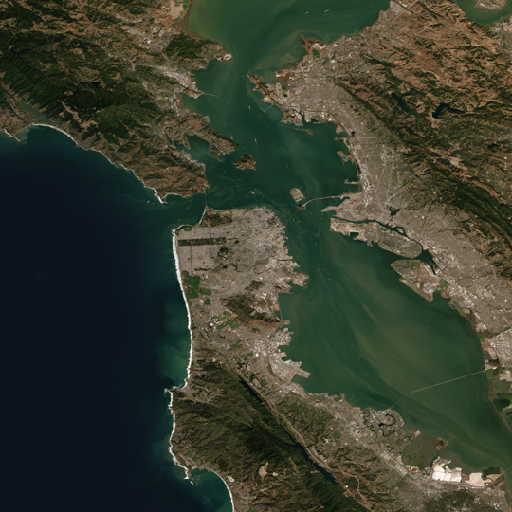

In [13]:
client = examples.get_san_francisco()
client

## 3. 获取瓦片和缩略图

要获取单个瓦片（z, x, y）：

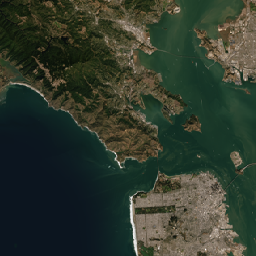

In [14]:
client.tile(10, 163, 395)

要生成缩略图预览：

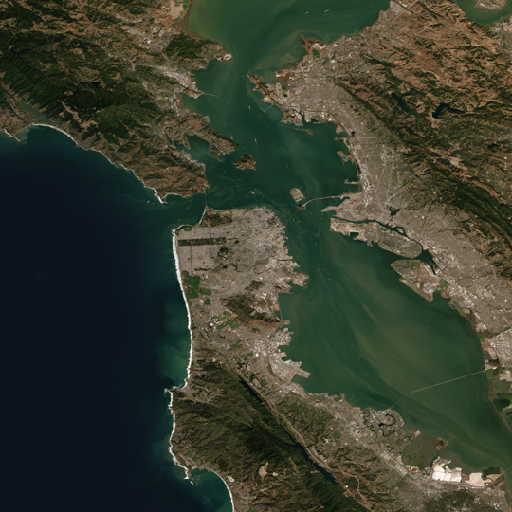

In [15]:
client.thumbnail()

## 4. 与ipyleaflet集成

要在**ipyleaflet**地图上显示栅格数据：

In [16]:
from ipyleaflet import Map

client = examples.get_elevation()
tile_layer = get_leaflet_tile_layer(
    client, indexes=1, vmin=-5000, vmax=5000, opacity=0.65
)

m = Map(zoom=3)
m.add(tile_layer)
m

InvalidURL: Failed to parse: http://::1:59353/api/metadata?&filename=d%3A%5Csoft%5Cgeo_program%5Cvenv311%5CLib%5Csite-packages%5Clocaltileserver%5Ctiler%5Cdata%5Caws_elevation_tiles_prod.xml

## 5. 与Folium集成

要在**folium**地图上显示栅格数据：

In [ ]:
from folium import Map

client = examples.get_oam2()
tile_layer = get_folium_tile_layer(client)

m = Map(location=client.center(), zoom_start=16)
m.add_child(tile_layer)
m

## 总结
- **localtileserver**将栅格数据作为交互式瓦片图层提供服务。
- 与**folium**和**ipyleaflet**无缝集成。
- 支持本地和远程栅格文件，包括COG。
- 允许使用颜色映射和重采样方法进行自定义。

## 进一步阅读
- [localtileserver文档](https://github.com/banesullivan/localtileserver)
- [Folium文档](https://python-visualization.github.io/folium/)
- [ipyleaflet文档](https://ipyleaflet.readthedocs.io/)

---

### 作业
1. 安装**localtileserver**并服务本地栅格文件。
2. 在**folium**和**ipyleaflet**中可视化栅格数据。
3. 应用颜色映射来自定义可视化效果。
4. 提交包含实现的Jupyter Notebook。

### 反馈
如果您遇到问题或有功能请求，请在[localtileserver GitHub页面](https://github.com/banesullivan/localtileserver/discussions)上开启讨论或提交issue。

要调试，请生成系统报告：

In [ ]:
import localtileserver

print(localtileserver.Report())

愉快地绘图！🌍